In [2]:

import pandas as pd
import numpy as np


df=pd.read_csv('Titanic_train.csv')
import seaborn as sns
import matplotlib.pyplot as plt
import sklearn


In [3]:

## New feature
##(Family=parch (number of parents + children)
## +SibSp(brothers and sisters(siblings)+spouses(husband or wife))+1(person himself))

df['Family']=df['SibSp']+df['Parch']+1
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
 12  Family       891 non-null    int64  
dtypes: float64(2), int64(6), str(5)
memory usage: 90.6 KB


In [4]:

df.drop('SibSp', axis=1, inplace=True)
df.drop('Parch', axis=1, inplace=True)
df.drop('PassengerId', axis=1, inplace=True)
df.drop('Name', axis=1, inplace=True)
df.drop('Ticket', axis=1, inplace=True)
df.drop('Cabin', axis=1, inplace=True)
# Cabin has 687 null then we will drop it
# Age   has 177 null


In [5]:

##Check duplicate and nulls
print(df.duplicated().sum())
print(df.isna().sum())


112
Survived      0
Pclass        0
Sex           0
Age         177
Fare          0
Embarked      2
Family        0
dtype: int64


In [6]:

# Handling nulls & duplicates & Outliers

# -> median cover nulls in Age
median_age=df['Age'].median()
df['Age']=df['Age'].fillna(median_age)

# -> Drop duplicates
df.drop_duplicates( inplace=True)


In [7]:
# describe Numrical cols
df.describe()


,Survived,Pclass,Age,Fare,Family
count,774.000000,774.000000,774.000000,774.000000,774.000000
mean,0.412145,2.245478,29.583230,34.894579,1.948320
std,0.492539,0.853695,13.775143,52.440426,1.523398
min,0.000000,1.000000,0.420000,0.000000,1.000000
25%,0.000000,1.000000,21.000000,8.050000,1.000000
50%,0.000000,3.000000,28.000000,15.900000,1.000000
75%,1.000000,3.000000,36.000000,34.286450,2.000000
max,1.000000,3.000000,80.000000,512.329200,11.000000


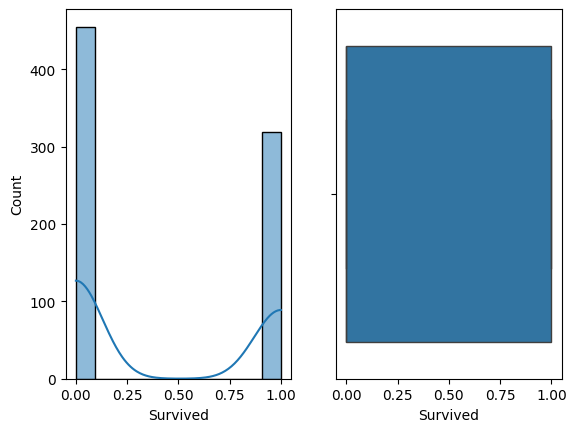

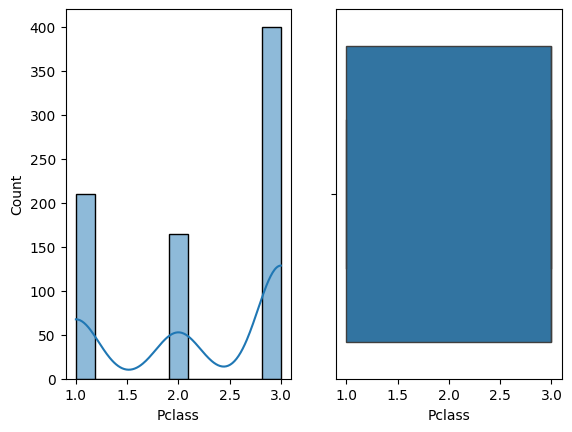

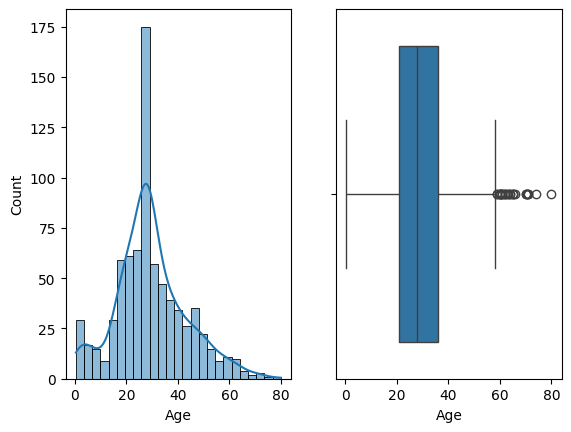

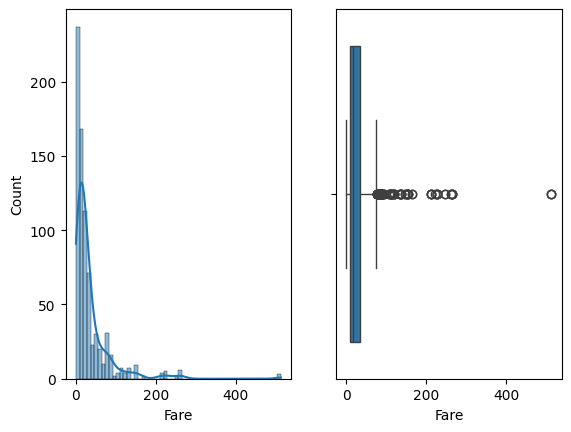

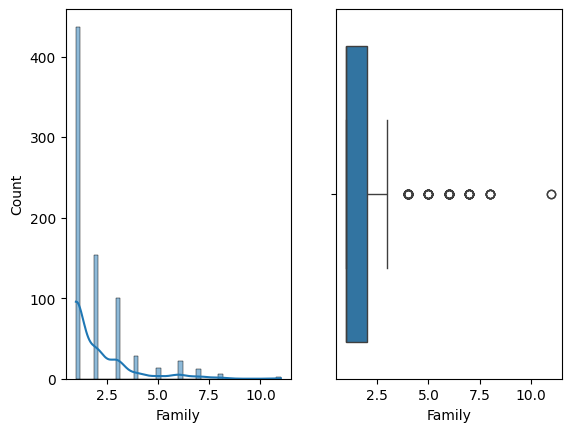

In [8]:
##    To see the graphs of the numerical data
for col in df.select_dtypes('number').columns:
         fig, ax = plt.subplots(1,2)
         sns.histplot(x=df[col],kde=True,ax=ax[0])
         sns.boxplot(x=df[col], ax=ax[1])
         plt.show()

In [9]:

# -> Removing outliers
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]

for col in ['Age', 'Fare','Family']:
    df = remove_outliers(df, col)

print("the number of duplicated=",df.duplicated().sum())
print(df.isna().sum())





the number of duplicated= 0
Survived    0
Pclass      0
Sex         0
Age         0
Fare        0
Embarked    0
Family      0
dtype: int64


In [10]:

## Univariate analysis
##    To see the graphs of the numerical data
    # for col in df.select_dtypes('number').columns:
    #     fig, ax = plt.subplots(1,2)
    #     sns.histplot(x=df[col],kde=True,ax=ax[0])
    #     sns.boxplot(x=df[col], ax=ax[1])
    #     plt.show()

# #    To see the graphs of the Categorical data

#for col in df.select_dtypes(include=['object']).columns:
#    sns.countplot(x=df[col])
#    plt.show()

# # Bivariate analysis
# sns.heatmap(df.corr(numeric_only=True), annot=True)
# sns.pairplot(df)


df


,Survived,Pclass,Sex,Age,Fare,Embarked,Family
0,0,3,male,22.0,7.2500,S,2
2,1,3,female,26.0,7.9250,S,1
3,1,1,female,35.0,53.1000,S,2
4,0,3,male,35.0,8.0500,S,1
5,0,3,male,28.0,8.4583,Q,1
...,...,...,...,...,...,...,...
882,0,3,female,22.0,10.5167,S,1
883,0,2,male,28.0,10.5000,S,1
887,1,1,female,19.0,30.0000,S,1
889,1,1,male,26.0,30.0000,C,1


In [11]:


# Test train split
from sklearn.model_selection import train_test_split
x=df.drop('Survived', axis=1)
y=df['Survived']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,shuffle=True)

x_train.shape,x_test.shape,y_train.shape,y_test.shape


((462, 6), (116, 6), (462,), (116,))

In [12]:


# Encoding

# Nominal columns
train_cat=x_train.select_dtypes(['object','string'])
test_cat=x_test.select_dtypes(['object','string'])

from sklearn.preprocessing import OneHotEncoder

ohe=OneHotEncoder(sparse_output=False,drop='first',handle_unknown='ignore')
train_cat_ohe=ohe.fit_transform(train_cat)
test_cat_ohe=ohe.transform(test_cat)


# Ordinal columns > Pclass "Passenger Class" which is already ready (Doesnt need encoding)



In [13]:

##Scaling
from sklearn.preprocessing import StandardScaler
train_num=x_train[['Age', 'Fare','Family']]
test_num=x_test[['Age', 'Fare','Family']]


scaler=StandardScaler()
train_num_scaled =scaler.fit_transform(train_num)
test_num_scaled =scaler.transform(test_num)

# 2D shape To be accepted by the concatenation
train_pclass = x_train[['Pclass']].to_numpy()
test_pclass  = x_test[['Pclass']].to_numpy()



train = np.concatenate((train_num_scaled, train_cat_ohe, train_pclass), axis=1)
test  = np.concatenate((test_num_scaled, test_cat_ohe, test_pclass), axis=1)
print(train)

[[ 0.55234213 -0.77019169 -0.64378537 ...  0.          1.
   3.        ]
 [-0.80473017 -0.65228412 -0.64378537 ...  0.          1.
   3.        ]
 [ 0.73328511 -0.70621084  2.16214711 ...  0.          1.
   3.        ]
 ...
 [-0.08095827 -0.36071426 -0.64378537 ...  0.          1.
   2.        ]
 [-0.08095827  2.5165959   0.75918087 ...  0.          1.
   1.        ]
 [ 0.68804936  0.61545069  2.16214711 ...  0.          1.
   2.        ]]


In [ ]:

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score ,classification_report
def trainAndEvaluate(model):
    model.fit(train,y_train)
    pred=model.predict(test)
    trainAccuracy= model.score(train,y_train)
    testAccuracy=accuracy_score(y_test,pred)
    print("Train Accuracy : " , trainAccuracy * 100 , "%")
    print("Test Accuracy : " , testAccuracy * 100 , "%")
    print("================================")
    print(classification_report(y_test, pred))
    print("================================")

In [15]:
model1=LogisticRegression(C=1.0,penalty="l2",max_iter=100)
trainAndEvaluate(model1)

Train Accuracy :  77.27272727272727 %
Test Accuracy :  76.72413793103449 %
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        73
           1       0.70      0.65      0.67        43

    accuracy                           0.77       116
   macro avg       0.75      0.74      0.75       116
weighted avg       0.76      0.77      0.77       116



d:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


In [16]:
model2=DecisionTreeClassifier(
   max_depth=15,
    min_samples_split=20,
    min_samples_leaf=2,
   
)
trainAndEvaluate(model2)

Train Accuracy :  85.71428571428571 %
Test Accuracy :  80.17241379310344 %
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        73
           1       0.76      0.67      0.72        43

    accuracy                           0.80       116
   macro avg       0.79      0.78      0.78       116
weighted avg       0.80      0.80      0.80       116



In [17]:

model3=SVC(C=1.0,kernel="rbf")
trainAndEvaluate(model3)

Train Accuracy :  79.22077922077922 %
Test Accuracy :  77.58620689655173 %
              precision    recall  f1-score   support

           0       0.80      0.86      0.83        73
           1       0.73      0.63      0.68        43

    accuracy                           0.78       116
   macro avg       0.76      0.75      0.75       116
weighted avg       0.77      0.78      0.77       116



In [43]:
model4=GradientBoostingClassifier(
    n_estimators=25,
    max_depth=10,
    min_samples_leaf=10
)
trainAndEvaluate(model4)

Train Accuracy :  87.44588744588745 %
Test Accuracy :  77.58620689655173 %
              precision    recall  f1-score   support

           0       0.81      0.84      0.82        73
           1       0.71      0.67      0.69        43

    accuracy                           0.78       116
   macro avg       0.76      0.76      0.76       116
weighted avg       0.77      0.78      0.77       116



In [44]:
# choosing the best model

models=[model1,model2,model3,model4]
best_model = None
best_accuracy = 0.0
for i in models:
    print(i)
    trainAndEvaluate(i) 
    testAccuracy=accuracy_score(y_test, i.predict(test))
    if  testAccuracy > best_accuracy:
       best_accuracy = testAccuracy
       best_model = i

print("Best Model:", best_model)
print("Best Accuracy:", best_accuracy * 100, "%")

LogisticRegression(penalty='l2')
Train Accuracy :  77.27272727272727 %
Test Accuracy :  76.72413793103449 %
              precision    recall  f1-score   support

           0       0.80      0.84      0.82        73
           1       0.70      0.65      0.67        43

    accuracy                           0.77       116
   macro avg       0.75      0.74      0.75       116
weighted avg       0.76      0.77      0.77       116

DecisionTreeClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=20)
Train Accuracy :  85.71428571428571 %
Test Accuracy :  80.17241379310344 %
              precision    recall  f1-score   support

           0       0.82      0.88      0.85        73
           1       0.76      0.67      0.72        43

    accuracy                           0.80       116
   macro avg       0.79      0.78      0.78       116
weighted avg       0.80      0.80      0.80       116

SVC()
Train Accuracy :  79.22077922077922 %
Test Accuracy :  77.58620689655173 %
   

d:\Python\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Train Accuracy :  87.44588744588745 %
Test Accuracy :  77.58620689655173 %
              precision    recall  f1-score   support

           0       0.81      0.84      0.82        73
           1       0.71      0.67      0.69        43

    accuracy                           0.78       116
   macro avg       0.76      0.76      0.76       116
weighted avg       0.77      0.78      0.77       116

Best Model: DecisionTreeClassifier(max_depth=15, min_samples_leaf=2, min_samples_split=20)
Best Accuracy: 80.17241379310344 %
